<a href="https://colab.research.google.com/github/sreelekaa/Decision-Tree-and-Random-Forest/blob/main/DT_and_Randaom_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('heart.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


split features and target

In [ ]:
X=df.drop('target',axis=1)
Y=df['target']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_X,test_X,train_Y,test_Y=train_test_split(X,Y,test_size=0.2,random_state=42)

Train a decision tree clasifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt

In [ ]:
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(train_X,train_Y)

DecisionTreeClassifier(random_state=42)

Visualize the Decision Tree

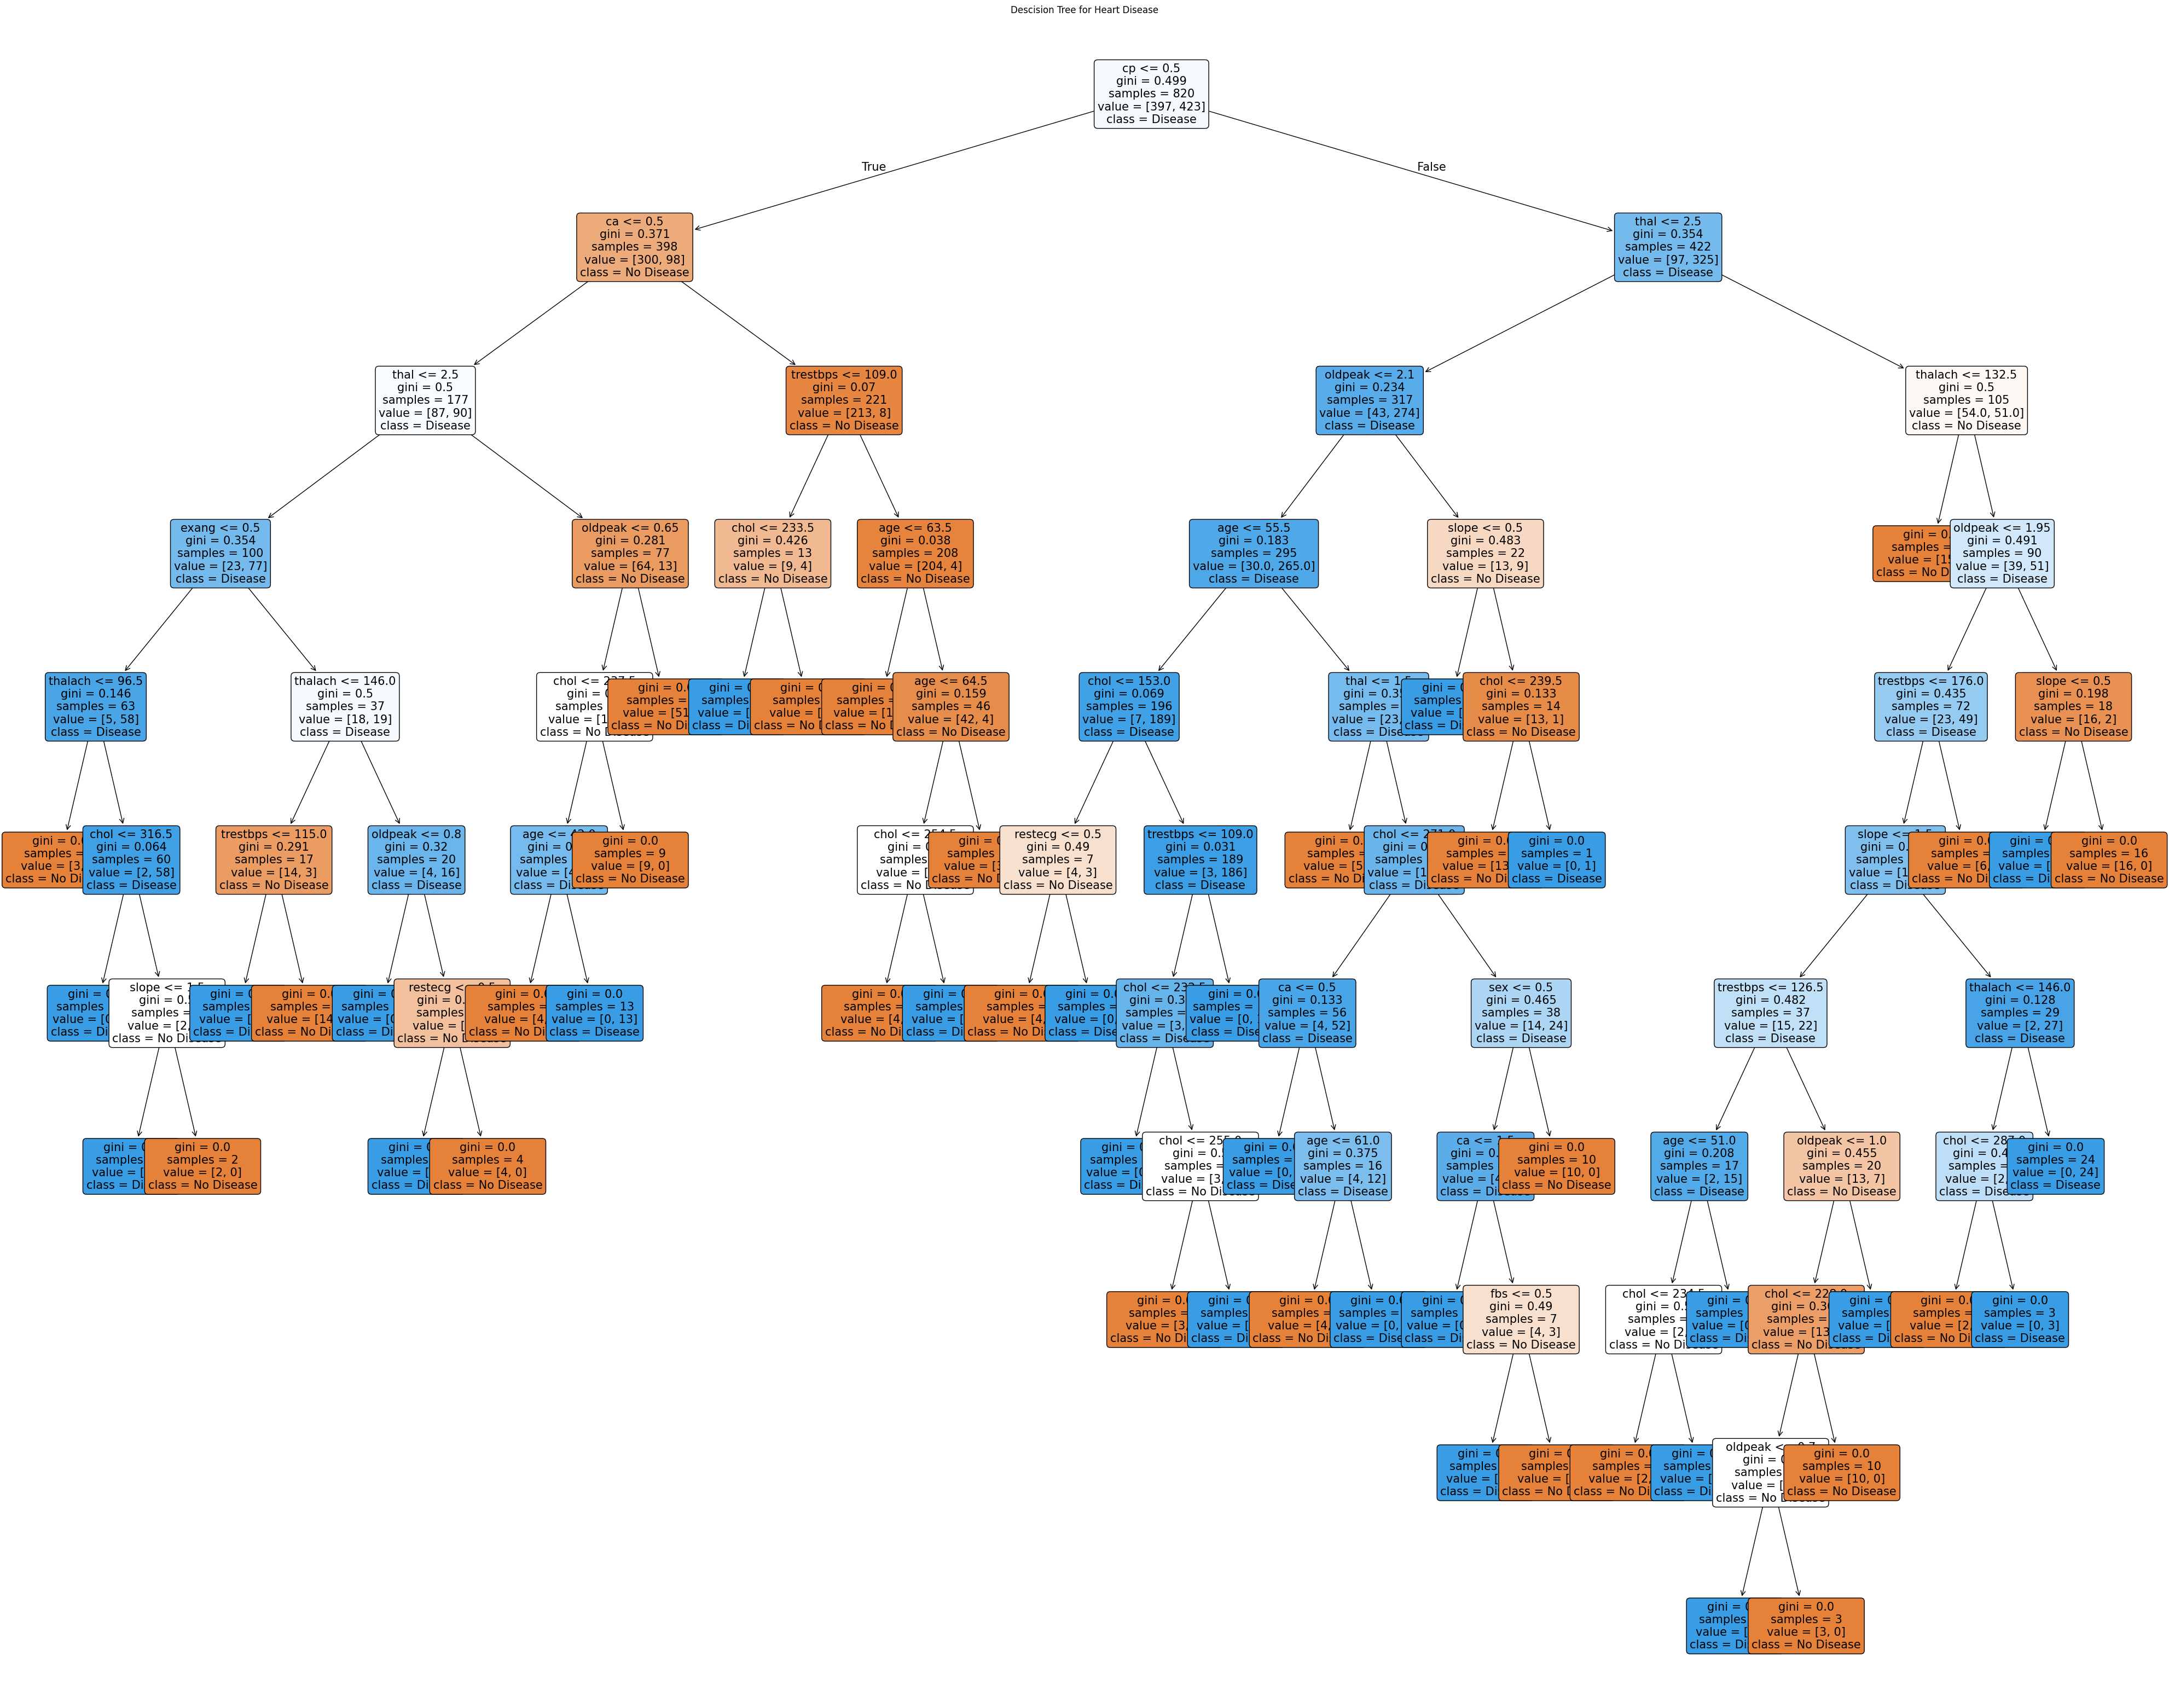

In [ ]:
plt.figure(figsize=(50,40))
plot_tree(dt_model,feature_names=X.columns,class_names=['No Disease','Disease'],filled=True,rounded=True,fontsize=15)
plt.title("Descision Tree for Heart Disease")
plt.show()

Controlling Overfitting with max_depth                                               
 Train a Pruned (Shallower) Tree

In [ ]:
df_pruned=DecisionTreeClassifier(max_depth=4,random_state=42)
df_pruned.fit(train_X,train_Y)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
Y_train_pred=df_pruned.predict(train_X)
Y_test_pred=df_pruned.predict(test_X)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
train_acc=accuracy_score(train_Y,Y_train_pred)
test_acc=accuracy_score(test_Y,Y_test_pred)

In [ ]:
print(f"Train Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")

Train Accuracy: 0.88
Test Accuracy: 0.80


In [ ]:
unpruned_train_acc = dt_model.score(train_X, train_Y)
unpruned_test_acc = dt_model.score(test_X, test_Y)

In [ ]:
print(f"Unpruned Train Accuracy: {unpruned_train_acc:.2f}")
print(f"Unpruned Test Accuracy: {unpruned_test_acc:.2f}")

Unpruned Train Accuracy: 1.00
Unpruned Test Accuracy: 0.99


Your unpruned decision tree perfectly memorizes the training data, but that may not generalize well to unseen data in a real-world scenario.

Your pruned tree generalizes better, though at the cost of some accuracy.

Even though your test accuracy is still high in both cases, in larger or noisier datasets, the difference would be more drastic.

Random Forest generally reduces overfitting by averaging multiple trees.

You should see:

Train Accuracy slightly less than 1.0

Test Accuracy better or at least comparable to the pruned tree



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Initialize and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None,random_state=42)
rf_model.fit(train_X, train_Y)


RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
# Make predictions
y_train_pred_rf = rf_model.predict(train_X)
y_test_pred_rf = rf_model.predict(test_X)

In [ ]:
# Evaluate accuracy
rf_train_acc = accuracy_score(train_Y, y_train_pred_rf)
rf_test_acc = accuracy_score(test_Y, y_test_pred_rf)

In [ ]:

print(f"Random Forest Train Accuracy: {rf_train_acc:.2f}")
print(f"Random Forest Test Accuracy: {rf_test_acc:.2f}")


Random Forest Train Accuracy: 1.00
Random Forest Test Accuracy: 0.99


In [ ]:
# Get feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

In [ ]:
# Create a DataFrame for better readability
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,  # Column names (features)
    'Importance': importances  # Feature importances
})


In [ ]:

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print(feature_importance_df)


     Feature  Importance
2         cp    0.136494
11        ca    0.123180
12      thal    0.122048
7    thalach    0.119684
9    oldpeak    0.117045
0        age    0.079199
4       chol    0.078098
3   trestbps    0.069589
8      exang    0.055335
10     slope    0.043412
1        sex    0.028806
6    restecg    0.018946
5        fbs    0.008162


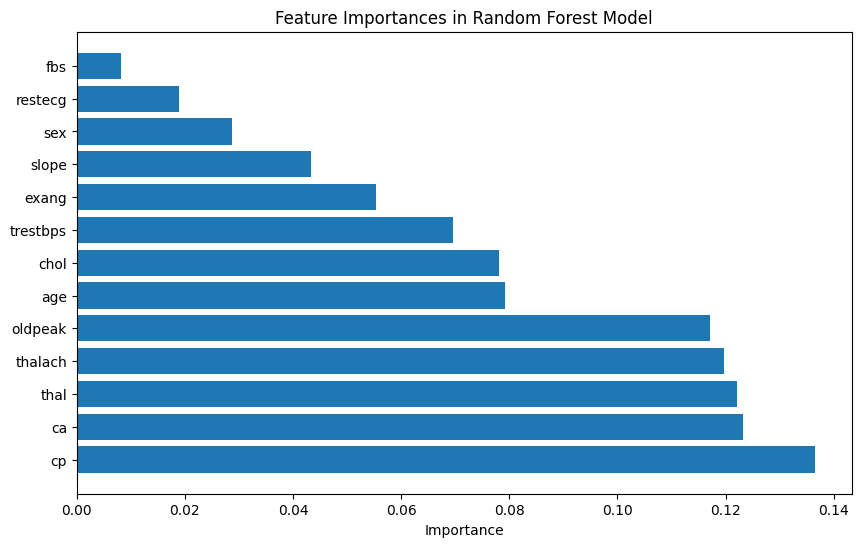

In [ ]:
# Optional: Visualize the feature importances
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances in Random Forest Model')
plt.show()


Evaluate Using Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
# Perform cross-validation for the Random Forest model
cv_scores = cross_val_score(rf_model, X, Y, cv=5)  # 5-fold cross-validation


In [ ]:

# Print out cross-validation scores
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.2f}")

Cross-Validation Scores: [1.         1.         1.         1.         0.98536585]
Mean CV Score: 1.00
